# PApple RGB / Depth Alignment Check

Verifies whether the converted PApple Depth maps actually align spatially with the RGB images.

Three checks:
1. **Visual** — RGB / Depth / annotation-overlay side-by-side for random + flagged samples.
2. **Edge agreement** — Canny edges on RGB vs Sobel-gradient edges on Depth. If the modalities align, edges should coincide on fruit boundaries; we compute an IoU and an edge-precision metric within a dilated tolerance band.
3. **Dataset-wide** — distributions from `_alignment_report.json` (valid-depth fraction inside fruit masks, depth range).

Split: **train** (per request).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from PIL import Image, ImageDraw
from scipy import ndimage as ndi

try:
    from skimage.feature import canny
    from skimage.filters import sobel
except ImportError as e:
    raise SystemExit("This notebook needs scikit-image: pip install scikit-image") from e

ROOT = Path.cwd()
PAPPLE = ROOT / "data" / "PApple"
RGB_DIR = PAPPLE / "RGB"
DEPTH_DIR = PAPPLE / "Depth"
SPLIT = "train"

assert PAPPLE.exists(), f"Missing {PAPPLE} — run notebook from repo root"

with open(PAPPLE / f"{SPLIT}_1class.JSON") as f:
    coco = json.load(f)

imgs = {im["id"]: im for im in coco["images"]}
anns_by_img = {}
for a in coco["annotations"]:
    anns_by_img.setdefault(a["image_id"], []).append(a)

print(f"{SPLIT}: {len(imgs)} images, {len(coco['annotations'])} annotations")

train: 2290 images, 8579 annotations


In [2]:
def stem_for(im):
    return Path(im["file_name"]).stem.replace("_RGB", "")

def load_pair(im):
    rgb = np.asarray(Image.open(RGB_DIR / im["file_name"]).convert("RGB"))
    depth = np.asarray(Image.open(DEPTH_DIR / f"{stem_for(im)}_DEPTH.tiff").convert("L"))
    return rgb, depth

def rasterize_fruit_mask(anns, h, w):
    img = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(img)
    polys = []
    for ann in anns:
        flat = ann["segmentation"][0]
        pts = list(zip(flat[0::2], flat[1::2]))
        if len(pts) < 3:
            continue
        draw.polygon(pts, fill=1)
        polys.append(np.array(pts))
    return np.asarray(img, dtype=bool), polys

## 1. Side-by-side visual check

For each sample we plot: RGB, Depth (viridis, zero = invalid in black), and an RGB-with-fruit-polygons overlay. If RGB and Depth align, the high-gradient regions in the depth map should sit on top of the same fruit silhouettes outlined in the third panel.

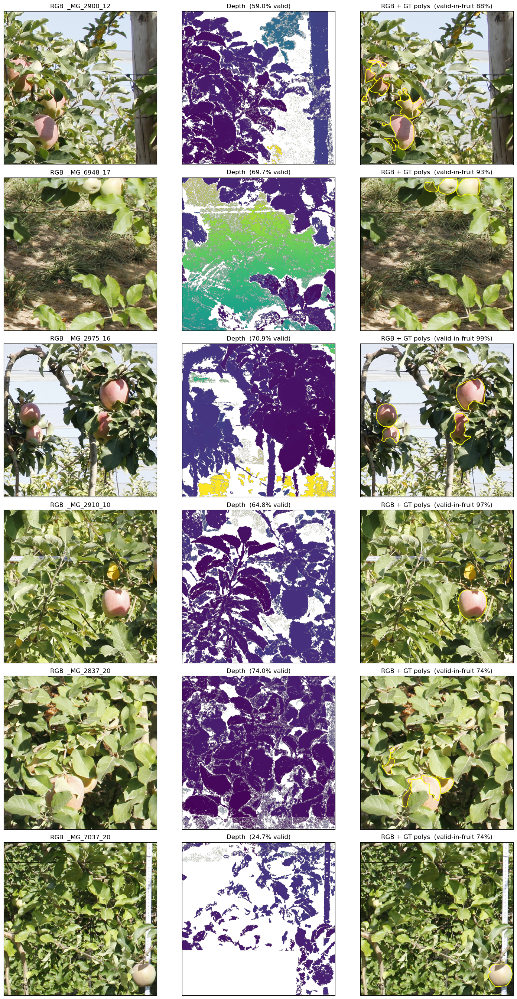

In [3]:
def show_pair(im, ax_row):
    rgb, depth = load_pair(im)
    h, w = depth.shape
    anns = anns_by_img.get(im["id"], [])
    fruit, polys = rasterize_fruit_mask(anns, h, w)

    ax_row[0].imshow(rgb)
    ax_row[0].set_title(f"RGB  {stem_for(im)}")

    masked_depth = np.where(depth > 0, depth, np.nan)
    ax_row[1].imshow(masked_depth, cmap="viridis")
    ax_row[1].set_title(f"Depth  ({(depth>0).mean()*100:.1f}% valid)")

    ax_row[2].imshow(rgb)
    patches = [MplPolygon(p, closed=True) for p in polys]
    pc = PatchCollection(patches, facecolor="none", edgecolor="yellow", linewidth=1.2)
    ax_row[2].add_collection(pc)
    valid_in_fruit = (fruit & (depth > 0)).sum() / max(fruit.sum(), 1)
    ax_row[2].set_title(f"RGB + GT polys  (valid-in-fruit {valid_in_fruit*100:.0f}%)")

    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

rng = np.random.default_rng(0)
ids = list(imgs.keys())
sample_ids = rng.choice(ids, size=6, replace=False)

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(15, 4.5 * len(sample_ids)))
for r, sid in enumerate(sample_ids):
    show_pair(imgs[sid], axes[r])
plt.tight_layout(); plt.show()

### Flagged samples (from `_alignment_report.json`)
These are images the alignment script flagged as having `<30 %` valid depth inside the fruit masks. Useful to see what bad alignment / sparse depth actually looks like.

5 flagged train images


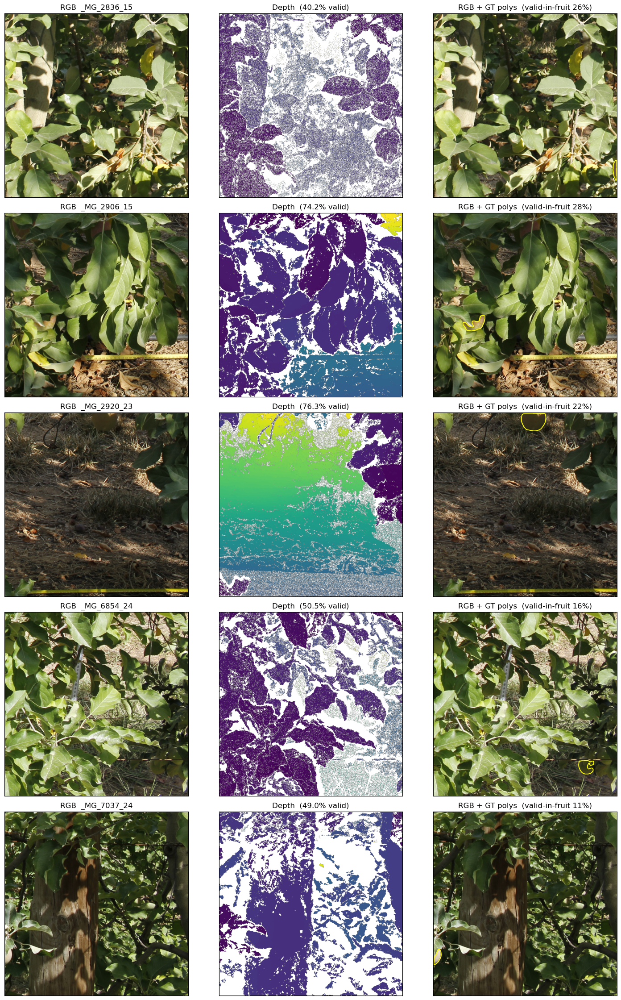

In [4]:
report = json.loads((PAPPLE / "_alignment_report.json").read_text())
flagged_train = [f for f in report["flagged_images"] if f.get("split") == SPLIT]
print(f"{len(flagged_train)} flagged train images")

stem_to_id = {stem_for(im): im["id"] for im in imgs.values()}
flagged_ids = [stem_to_id[f["stem"]] for f in flagged_train if f["stem"] in stem_to_id]

if flagged_ids:
    fig, axes = plt.subplots(len(flagged_ids), 3, figsize=(15, 4.5 * len(flagged_ids)))
    if len(flagged_ids) == 1:
        axes = axes[None, :]
    for r, sid in enumerate(flagged_ids):
        show_pair(imgs[sid], axes[r])
    plt.tight_layout(); plt.show()
else:
    print("No flagged train images.")

## 2. Edge-agreement metric

If RGB and Depth are aligned, object boundaries should fire in **both** modalities at the same pixels. We compute:

- `rgb_edges`  = Canny on grayscale RGB
- `depth_edges` = Sobel-magnitude on depth (valid pixels only), thresholded at the 90th percentile
- `tolerance` band: depth edges dilated by 3 px (depth boundaries are blockier than RGB)
- **`edge_recall`** = fraction of RGB edge pixels that fall within the dilated depth-edge band
- **`edge_iou`** = IoU between dilated RGB edges and dilated depth edges

A well-aligned pair should score `edge_recall ≳ 0.4`; misaligned pairs (shift / wrong scaling) typically fall below 0.2. (These are heuristic thresholds — the *distribution* across the dataset is more informative than any one number.)

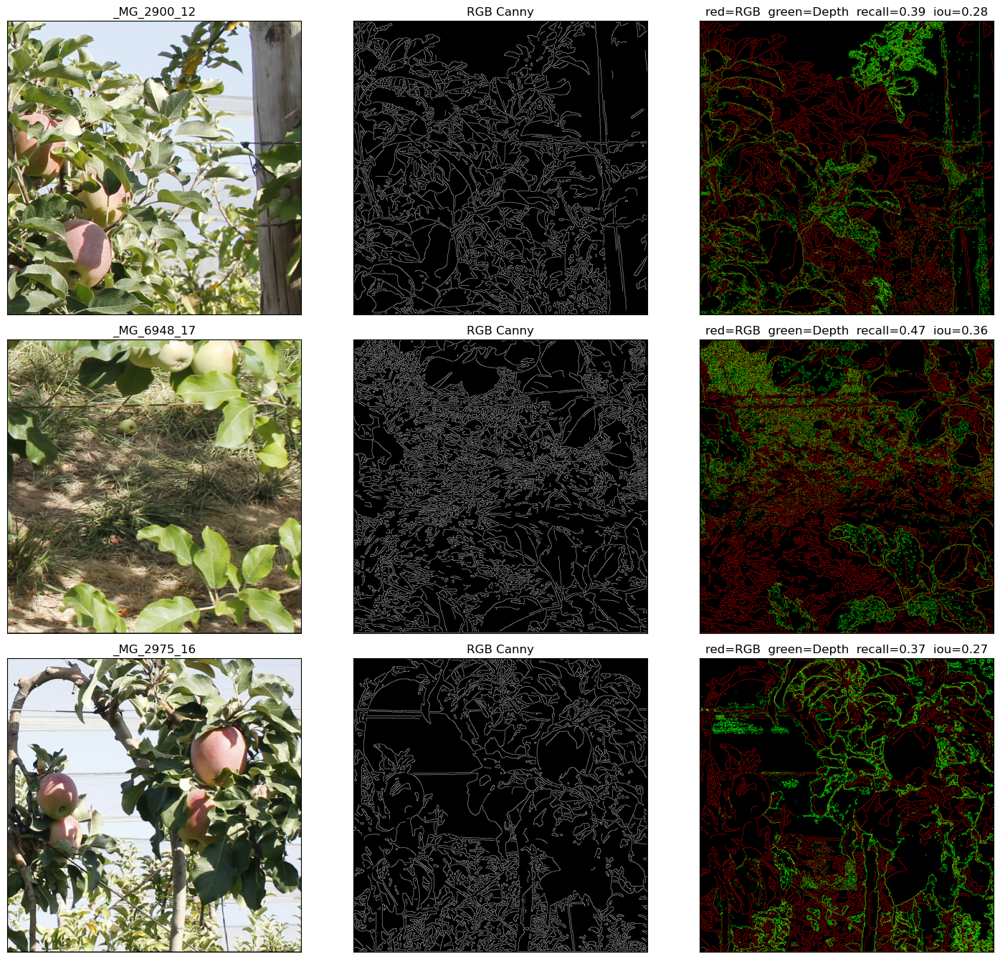

In [5]:
def edge_agreement(rgb, depth, tol_px=3):
    gray = rgb.mean(axis=2) / 255.0
    rgb_edges = canny(gray, sigma=2.0)

    valid = depth > 0
    if valid.sum() < 100:
        return None
    d = depth.astype(np.float32)
    d[~valid] = np.nan
    # fill NaNs with local mean so Sobel doesn't blow up at invalid borders
    d_filled = np.where(valid, d, np.nanmean(d))
    grad = sobel(d_filled)
    thresh = np.percentile(grad[valid], 90)
    depth_edges = (grad > thresh) & valid

    depth_band = ndi.binary_dilation(depth_edges, iterations=tol_px)
    rgb_band = ndi.binary_dilation(rgb_edges, iterations=tol_px)

    n_rgb = rgb_edges.sum()
    recall = (rgb_edges & depth_band).sum() / max(n_rgb, 1)
    inter = (rgb_band & depth_band).sum()
    union = (rgb_band | depth_band).sum()
    iou = inter / max(union, 1)
    return {
        "edge_recall": float(recall),
        "edge_iou": float(iou),
        "rgb_edges": rgb_edges,
        "depth_edges": depth_edges,
    }

# show edge maps for a couple of samples
demo_ids = sample_ids[:3]
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 4.5 * len(demo_ids)))
for r, sid in enumerate(demo_ids):
    rgb, depth = load_pair(imgs[sid])
    res = edge_agreement(rgb, depth)
    axes[r,0].imshow(rgb); axes[r,0].set_title(stem_for(imgs[sid]))
    axes[r,1].imshow(res["rgb_edges"], cmap="gray"); axes[r,1].set_title("RGB Canny")
    overlay = np.zeros((*res["rgb_edges"].shape, 3))
    overlay[..., 0] = res["rgb_edges"]
    overlay[..., 1] = res["depth_edges"]
    axes[r,2].imshow(overlay)
    axes[r,2].set_title(f"red=RGB  green=Depth  recall={res['edge_recall']:.2f}  iou={res['edge_iou']:.2f}")
    for ax in axes[r]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Distribution of edge-agreement across the train split
Random subsample (200 images by default — bump if you want tighter estimates).

  50/200
  100/200
  150/200
  200/200
edge_recall  mean=0.351  median=0.351  min=0.026
edge_iou     mean=0.237  median=0.236  min=0.017


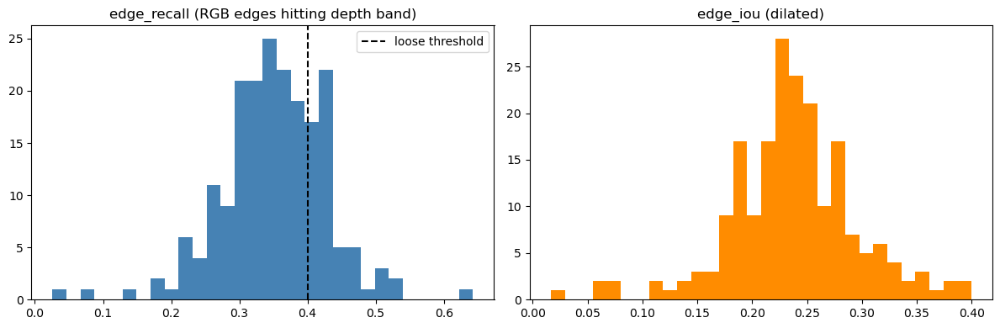

In [6]:
N_SAMPLE = 200
subset = rng.choice(ids, size=min(N_SAMPLE, len(ids)), replace=False)

recalls, ious = [], []
for k, sid in enumerate(subset):
    rgb, depth = load_pair(imgs[sid])
    res = edge_agreement(rgb, depth)
    if res is None:
        continue
    recalls.append(res["edge_recall"])
    ious.append(res["edge_iou"])
    if (k + 1) % 50 == 0:
        print(f"  {k+1}/{len(subset)}")

recalls = np.array(recalls); ious = np.array(ious)
print(f"edge_recall  mean={recalls.mean():.3f}  median={np.median(recalls):.3f}  min={recalls.min():.3f}")
print(f"edge_iou     mean={ious.mean():.3f}  median={np.median(ious):.3f}  min={ious.min():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(recalls, bins=30, color="steelblue"); axes[0].set_title("edge_recall (RGB edges hitting depth band)"); axes[0].axvline(0.4, color="k", ls="--", label="loose threshold"); axes[0].legend()
axes[1].hist(ious, bins=30, color="darkorange"); axes[1].set_title("edge_iou (dilated)");
plt.tight_layout(); plt.show()

## 3. Dataset-wide alignment-report metrics

From `_alignment_report.json`: per-image valid-depth fraction inside fruit masks and depth range. A bimodal `valid_frac_in_fruit` distribution would suggest a subset of images are misaligned (depth covers a different region than the fruits).

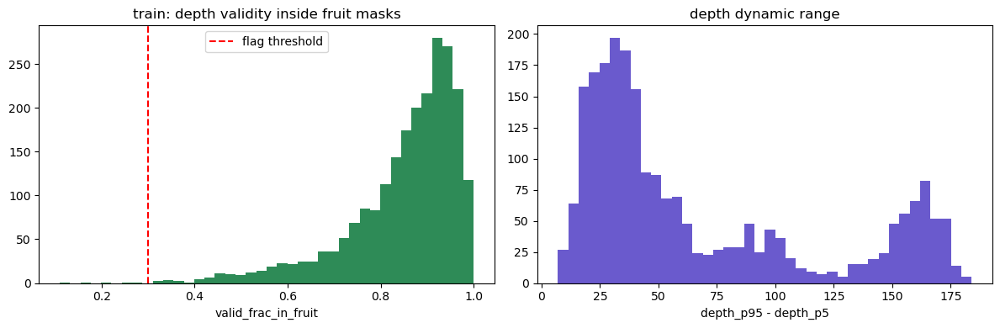

valid_frac_in_fruit  mean=0.851  median=0.884  <0.30: 5/2290


In [7]:
per_image = [r for r in report["per_image"] if r["split"] == SPLIT]
vf = np.array([r["valid_frac_in_fruit"] for r in per_image if r["valid_frac_in_fruit"] == r["valid_frac_in_fruit"]])
dr = np.array([r["depth_range"] for r in per_image])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vf, bins=40, color="seagreen")
axes[0].set_xlabel("valid_frac_in_fruit"); axes[0].set_title(f"{SPLIT}: depth validity inside fruit masks")
axes[0].axvline(0.3, color="red", ls="--", label="flag threshold"); axes[0].legend()
axes[1].hist(dr, bins=40, color="slateblue"); axes[1].set_xlabel("depth_p95 - depth_p5"); axes[1].set_title("depth dynamic range")
plt.tight_layout(); plt.show()

print(f"valid_frac_in_fruit  mean={vf.mean():.3f}  median={np.median(vf):.3f}  <0.30: {(vf<0.3).sum()}/{len(vf)}")

## Interpretation cheatsheet

| Signal | Aligned | Misaligned |
|---|---|---|
| Visual overlay (cell 1) | Depth-map fruit blobs sit under yellow polygons | Depth-map blobs offset / scaled differently |
| Red+green edge overlay | Mostly yellow (overlap) on fruit silhouettes | Parallel red & green lines (shift) |
| `edge_recall` distribution | Median ≳ 0.4 | Median < 0.2, long left tail |
| `valid_frac_in_fruit` | Strongly right-skewed, mode > 0.9 | Bimodal or shifted toward 0 |
